# 2. PSF modeling and subtraction

In this notebook, we demonstrate the PSF modeling and subtraction tools in coronspec_tools. We're going to use the offset files with the incidental source in the slit.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

In [3]:
import matplotlib as mpl
from matplotlib import pyplot as plt

In [4]:
from coronspec_tools import utils as ctutils
from coronspec_tools import misc as ctmisc

## List and organize the data files

I like to use a Pandas dataframe to organize my data files by metadata. Since all data files of the same type (e.g. sx1, sx2, flt, et cetera) have the same header keywords, they fit neatly into a dataframe format where the columns represent the keyword value and each row is a separate file. `coronspec_tools.utils` has some functions for setting this up.

In [5]:
# First, let's list all the data files available. Set your path as appropriate.
data_files = sorted(Path("../../data/MAST_2024-03-21T13_06_42.642Z/MAST_2024-03-21T13_06_42.642Z/HST/").glob("OF*/*fits"))

In [6]:
# for each file type, let's make a separate "file manager" dataframe using utils.organize_files_by_header(list_of_files)
file_managers = {}
for f in data_files:
    ftype = f.stem.split("_")[1]
    if ftype not in file_managers.keys():
        file_managers[ftype] = []
    file_managers[ftype].append(f)
for ft in file_managers:
    file_managers[ft] = ctutils.organize_files_by_header(file_managers[ft])

In [7]:
# we need the sx1 file, the unocculted exposure, and the occulted exposure. Looking at the Data Spreadsheet, these are:
sx1_rootname = 'OF0I02010'.lower()
unocc_rootname = 'OF0I02010'.lower()
occ_rootname = 'OF0I02020'.lower()

# the sx1 file is in the sx1 file manager:
sx1_file = file_managers['sx1'].set_index("ROOTNAME").loc[sx1_rootname]['filepath']
# we're going to use the _un_rectified 2-D spectral images
unocc_file = file_managers['flt'].set_index("ROOTNAME").loc[unocc_rootname]['filepath']
occ_file = file_managers['flt'].set_index("ROOTNAME").loc[occ_rootname]['filepath']

In [8]:
from coronspec_tools import observing_sequence
obs = observing_sequence.ObsSeq(
    sx1_file=sx1_file,
    unocc_file=unocc_file,
    occ_file=occ_file,
    trace_width = 11, # cut out a stamp of this width in rows around the unocculted trace
    occ_stamp_width = 101, # cut a stamp of this width in rows around the occulted star position
    median_clean = 10, # apply a median filter of this width in columns to smooth bad pixels
    contrast = False, # if True, divide by the unocculted spectrum to work in units of contrast    
)

In [9]:
from astropy import units

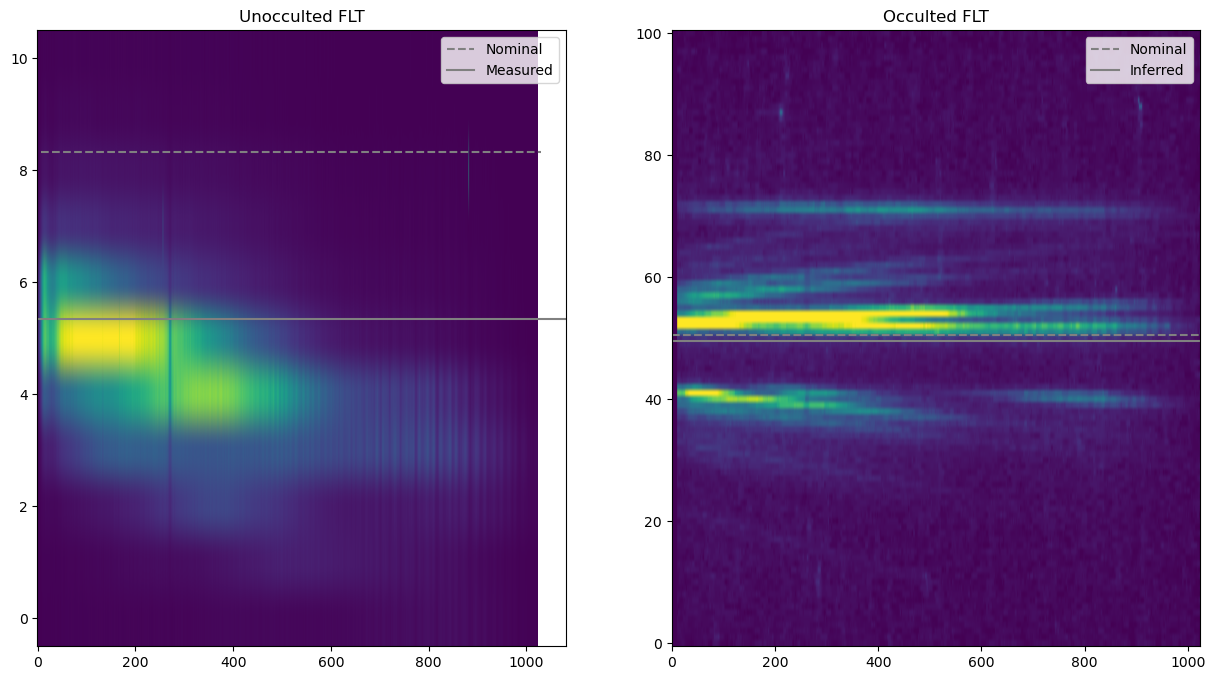

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
# fig.suptitle(hdr['TARGNAME'] + '\n' + hdr['ROOTNAME'] + '\n' + f"POSTARG2: {hdr['POSTARG2']}")
ax = axes[0]
ax.set_title("Unocculted FLT")
ax.imshow(
    obs.unocc_trace.data, 
    **ctmisc.img_vrange(obs.unocc_trace.data),
    origin='lower'
)
nominal_col, nominal_row = obs.unocc_wcs.world_to_pixel_values(
    obs.wlsol, 
    units.Quantity(0, unit='deg')
)

ax.plot(
    nominal_col,
    nominal_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='--', label='Nominal'
)
ax.axhline(
    obs.unocc_row - obs.unocc_trace.origin_original[1],
    c='gray', ls='-', label='Measured'
)
ax.legend()
ax.set_aspect("auto")

ax = axes[1]
ax.set_title("Occulted FLT")
ax.imshow(
    obs.occ_stamp.data, **ctmisc.img_vrange(obs.occ_stamp.data), origin='lower'
)
nominal_col, nominal_row = obs.occ_wcs.world_to_pixel_values(
    obs.wlsol.min(), 
    units.Quantity(0, unit='deg')
)
ax.axhline(nominal_row - obs.occ_stamp.origin_original[1], c='gray', ls='--', label='Nominal')
ax.axhline(obs.occ_stamp_center, c='gray', ls='-', label='Inferred')
ax.legend()
ax.set_aspect("auto")

The WCS doesn't follow the curvature of the trace, but, eh

## PSF Modeling and Subtraction

The module `sdi_tools.py` contains tools for managing PSF modeling and subtraction with spectral differential imaging. Our strategy is the following:

1. Scale by wavelength
   - In the original 2-d spectral images:
     - The speckles follow the 1/lambda spread of the on-axis PSF.
     - An off-axis source is dispersed straight down the row.
   - Choose a reference wavelength, `lambda_0`, and stretch each column by the factor `lambda_0/lambda_i`
     - The speckles will now be aligned with the rows
     - An off-axis PSF will follow a `1/lambda` path.
3. Interpolate under the PSF
   - Choose a row `r` for analysis in the original image, that has a real or hypothetical PSF from an off-axis companion
   - Make a copy of the image to serve as the PSF model
   - For a given width of the PSF in rows, compute the region where the upper and lower limits of the scaled PSF cross a row
   - Mask off this region, and interpolate the values of PSF
   - In the PSF model image, replace the data in the masked region with the interpolated values
5. Subtract the model from the data
6. Project the signal along the track of the scaled companion PSF back onto the original row.
   - For each column `c`, compute the nominal row coordinate of the PSF
   - Compute the distance-weighted mean of the nearest two pixels to the nominal position*
     - This choice of algorithm is semi-arbitrary
   - This is the value for the "descaled" residual for the coordinate `(x, y) = (c, r)`

In [11]:
from coronspec_tools import sdi_tools

In [15]:
obs.occ_stamp_center

np.float64(49.58928293708561)

In [16]:
ref_wl = 500 # scaling according to the longest wavelength index gives the steepest derivative
scale = obs.wlsol[ref_wl]/obs.wlsol
# use the WCS to compute the scaled PSF pixels
# the WCS assumes the FLT rectified, though so right now this doesn't matter
# scaled_img = sdi_tools.rescale_img_with_wcs(
#     obsseq.occ_img, 
#     obsseq.occ_wcs, 
#     obsseq.occ_sep, 
#     scale
# )
scaled_img = sdi_tools.rescale_img(
    obs.occ_stamp.data,
    obs.occ_stamp_center,
    scale
)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))
ax = axes[0]
ax.set_title("Original")
ax.imshow(obs.occ_stamp.data, **ctmisc.img_vrange(obs.occ_img, 0.05, 0.99), origin='lower', aspect='auto')

ax = axes[1]
ax.set_title("Rescaled")
ax.imshow(scaled_img, **ctmisc.img_vrange(scaled_img, 0.05, 0.99), origin='lower', aspect='auto')

# approximate track of companion
x = np.arange(obs.wlsol.size)
y = sdi_tools.compute_scaled_psf_trace(
    71, 
    obs.occ_stamp_center,
    scale
)
# alternate function that uses the WCS
# x, y = sdi_tools.compute_scaled_psf_trace_wcs(
#     obsseq.occ_stamp.wcs.pixel_to_world(0, 71)[1],
#     obsseq.occ_wcs,
#     obsseq.wlsol,
#     ref_wl,
# )
# y -= obsseq.occ_stamp.origin_original[1]

ax.plot(np.arange(y.size), y, ls='--', c='gray', alpha=1)

# for ax in axes.flat:
#     ax.set_ylim(400, 600)


We have identified a source at row 71 (in the stamp). In the flt image, the speckles are angled and the source is horizontal. In the rescaled image, the source follows a 1/lambda path, and the speckles are horizontal. This makes it easy to model a speckle, and where it crosses the PSF of the source, mask the source and replace the PSF values by interpolation.

Say a rescaled source PSF traverses rows 90-70 as wavelength increases. The function `sdi_tools.calc_wl_mask_position()` returns the wavelength (column) at which a speckle S on row R intersets with the PSF. Since the source PSF has a width of about 5 rowss

## Generate the pixel masks

The function `sdi_tools.calc_wl_mask_position` currently takes the reference wavelength *index*, rather than the wavelength itself. This needs to be corrected, because it introduces bugs if, for example, you index the wavelength from the end (e.g. `wlsol[-1]` instead of `wlsol[1023]`), or `wlsol[0]`. 

In [ ]:
test_row = 71

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 8), height_ratios=(3, 1))
for ax in axes:
    imax = ax.imshow(scaled_img, **ctmisc.img_vrange(scaled_img, 0.01, 0.95), cmap='plasma', origin='lower')
    ax.axhline(obs.occ_stamp_center, c='k', ls='--')
    ax.set_aspect("auto")
    
    # get the x, y values for the scaled companion trace
    x = np.arange(scaled_img.shape[1])
    psf_scaled_y = sdi_tools.compute_scaled_psf_trace(test_row, obs.occ_stamp_center, scale)
    ax.plot(np.arange(scaled_img.shape[1]), psf_scaled_y, c='gray')
    
    # let's calculate a mask for each row
    unique_rows = np.arange(np.floor(psf_scaled_y.min()), np.ceil(psf_scaled_y.max())+1, dtype=int)
    masks = {}
    for row_ind in unique_rows:
        center, width = sdi_tools.calc_wl_mask_position(
            test_row, row_ind, obs.occ_stamp_center, 7/2, obs.wlsol.to(units.Angstrom).value, ref_wl, obs.hdrs['occ']['sci']['CD1_1']
        )
        if center < 0 or center > scaled_img.shape[1]:
            # do not use this mask
            continue
        else:
            masks[row_ind] = (center, width)
    
    # plot the masks
    for row_ind, (mask_center, mask_width) in masks.items():
        ax.scatter(mask_center, row_ind, c='k', marker='|')
        mask = mpl.patches.Rectangle((mask_center-mask_width/2, row_ind-0.5), mask_width, 1, alpha=0.3, fc='k')
        ax.add_patch(mask)

axes.flat[1].set_ylim(unique_rows[0]-5, unique_rows[-1]+5) 

Bugs excepted, it works quite well at masking the relevant regions of the PSF.

## PSF interpolation

For each row, let's interpolate the PSF.

In [ ]:
col_inds = np.arange(obs.wlsol.size)
y_test = 71
row_ind = 75
y_ref = obs.occ_stamp_center
psf_width=5
wl_ref_ind = ref_wl
mask_center, mask_width = sdi_tools.calc_wl_mask_position(
    y_test,
    row_ind,
    y_ref,
    psf_width,
    obs.wlsol.to(units.Angstrom).value,
    wl_ref_ind,
    obs.hdrs['occ']['sci']['CD1_1']
)
mask = sdi_tools.make_row_mask(obs.wlsol.size, mask_center, mask_width)


In [ ]:
model_rows, model_masks, model, residual = sdi_tools.model_and_subtract_target(
    scaled_img = scaled_img, 
    obs=obs,
    y_test=71, 
    y_ref=obs.occ_stamp_center,
    wl_ref_ind=ref_wl,
    psf_width=7/2
)

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax = axes[0]
vrange = ctmisc.img_vrange(scaled_img)
imax = ax.imshow(scaled_img, origin='lower', aspect='auto', **vrange)

ax = axes[1]
ax.imshow(model[model_rows], origin='lower', aspect='auto', **vrange)

ax = axes[2]
ax.imshow(residual[model_rows], origin='lower', aspect='auto', **vrange)
fig.colorbar(imax, ax=axes)

In [ ]:
model_rows

In [ ]:
nrows = np.ceil(np.sqrt(unique_rows.size)).astype(int)
ncols = np.ceil(unique_rows.size/nrows).astype(int)
fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(4*ncols, 4*nrows),
    layout='constrained',
    sharex=False, sharey=False
)
for i, (ax, row_id, mask) in enumerate(zip(axes.flat, model_rows, model_masks)):
    ax.set_title(f"{row_id}")
    # get the mask
    mask = model_masks[row_id]
    masked_model = np.ma.masked_array(model[row_id], mask=~mask)
    
    ax.scatter(obs.wlsol[mask], scaled_img[row_id][mask], c='C0', label='Data', marker='.')
    ax.scatter(obs.wlsol[~mask], scaled_img[row_id][~mask], c='C0', alpha=0.5, marker='.')
    ax.scatter(obs.wlsol, masked_model, c='C1', label='Model', marker='.')
    ax.legend()
    ax.label_outer()